### Build a DNN using Keras with `RELU` and `ADAM`

#### Load tensorflow

In [0]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

#### Collect Fashion mnist data from tf.keras.datasets 

In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

4423680/4422102 [==============================] - 0s 0us/step


In [4]:
print("x_train shape:", X_train.shape, "y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28) y_train shape: (60000,)


In [5]:
print("Number of Train data - " + str(len(X_train)))
print("Number of Test data - " + str(len(X_test)))

Number of Train data - 60000
Number of Test data - 10000


In [0]:
#The fashion_mnist data: 60,000 train and 10,000 test data with 10 categories. 
# Each gray-scale image is 28x28.

#### Change train and test labels into one-hot vectors

In [0]:
y_train_hot = tf.keras.utils.to_categorical(y_train)
y_test_hot = tf.keras.utils.to_categorical(y_test)

#### Build the Graph

#### Initialize model, reshape & normalize data

In [0]:
#Normalize both the train and test image data from 0-255 to 0-1
X_train_norm = X_train/255
X_test_norm = X_test/255

In [9]:
#Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras
X_train_norm.shape

(60000, 28, 28)

In [0]:
X_train_norm = X_train_norm.reshape(-1,28,28,1)
X_test_norm = X_test_norm.reshape(-1,28,28,1)

In [11]:
#After Reshape
X_train_norm.shape

(60000, 28, 28, 1)

In [0]:
# Initialize model
model = tf.keras.models.Sequential()

#### Add two fully connected layers with 200 and 100 neurons respectively with `relu` activations. Add a dropout layer with `p=0.25`

In [0]:
#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,1)))

In [14]:
#Add 1st hidden layer
model.add(tf.keras.layers.Dense(200, activation='relu'))
#Add 2nd hidden layer
model.add(tf.keras.layers.Dense(100, activation='relu'))
#Add Dropout lasyer
model.add(tf.keras.layers.Dropout(0.25))

W0825 04:05:44.954563 139885803411328 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


### Add the output layer with a fully connected layer with 10 neurons with `softmax` activation. Use `categorical_crossentropy` loss and `adam` optimizer and train the network. And, report the final validation.

In [0]:
#Output Layer with 10 neurons
model.add(tf.keras.layers.Dense(10, activation='softmax'))

In [0]:
#Compile the model using Add the output layer with a fully connected layer with 10 neurons with softmax activation. 
# Use categorical_crossentropy loss and adam optimizer and train the network.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
## Take a look at the model summary
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape (Reshape)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 200)               157000    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               20100     
_________________________________________________________________
dropout (Dropout)            (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 178,110
Trainable params: 178,110
Non-trainable params: 0
_________________________________________________________________


In [18]:
# Fith the Model

history = model.fit(X_train_norm, y_train_hot,
                    validation_data=(X_test_norm, y_test_hot),
                    batch_size=32,
                    epochs=150)

Train on 60000 samples, validate on 10000 samples
Epoch 1/150
60000/60000 [==============================] - 6s 108us/sample - loss: 0.5148 - acc: 0.8159 - val_loss: 0.4246 - val_acc: 0.8450
Epoch 2/150
60000/60000 [==============================] - 6s 94us/sample - loss: 0.3867 - acc: 0.8591 - val_loss: 0.3874 - val_acc: 0.8583
Epoch 3/150
60000/60000 [==============================] - 6s 93us/sample - loss: 0.3476 - acc: 0.8723 - val_loss: 0.3801 - val_acc: 0.8602
Epoch 4/150
60000/60000 [==============================] - 6s 93us/sample - loss: 0.3243 - acc: 0.8824 - val_loss: 0.3531 - val_acc: 0.8731
Epoch 5/150
60000/60000 [==============================] - 6s 93us/sample - loss: 0.3037 - acc: 0.8881 - val_loss: 0.3648 - val_acc: 0.8707
Epoch 6/150
60000/60000 [==============================] - 6s 93us/sample - loss: 0.2906 - acc: 0.8904 - val_loss: 0.3443 - val_acc: 0.8738
Epoch 7/150
60000/60000 [==============================] - 6s 93us/sample - loss: 0.2789 - acc: 0.8960 - val_

In [0]:
import numpy as np
y_pred= model.predict(X_test_norm)
outs=[]
for val in y_pred:
    outs.append(np.argmax(val))


In [25]:
from sklearn import metrics
crl=metrics.confusion_matrix (y_test,outs)
print(crl)

[[827   1  19  17   1   2 127   0   6   0]
 [  5 974   3  11   2   0   4   0   1   0]
 [ 15   1 801   7  66   0 108   0   2   0]
 [ 20   6  14 903  29   0  25   0   3   0]
 [  1   0  85  25 812   0  75   0   2   0]
 [  0   0   0   1   0 955   0  25   1  18]
 [105   0  56  24  49   0 756   0  10   0]
 [  0   0   0   0   0   3   0 980   0  17]
 [  4   0   6   5   1   1   5   4 974   0]
 [  0   0   0   0   0   8   1  36   0 955]]


In [26]:
cr=metrics.classification_report(y_test,outs)
print(cr)

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.80      0.81      1000
           3       0.91      0.90      0.91      1000
           4       0.85      0.81      0.83      1000
           5       0.99      0.95      0.97      1000
           6       0.69      0.76      0.72      1000
           7       0.94      0.98      0.96      1000
           8       0.97      0.97      0.97      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



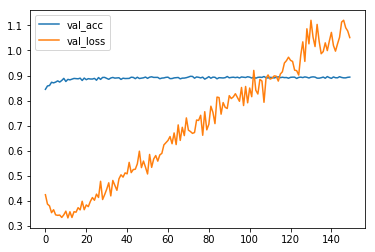

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_acc'])
plt.plot(history.history['val_loss'])
plt.legend(['val_acc', 'val_loss'], loc='upper left')

plt.show()


In [28]:
print("Final train Accuracy : ", history.history["acc"][-1])
print("Final test Accuracy : ", history.history["val_acc"][-1])

Final train Accuracy :  0.97421664
Final test Accuracy :  0.8937
